In [24]:
import scanpy as sc

# Load in read-only backed mode
#adata = sc.read_h5ad("data/Bladder_TSP1_30_version2d_10X_smartseq_scvi_Nov122024.h5ad", backed='r')
adata = sc.read_h5ad("data/Tabula_Sapiens_-_Blood__983d5ec9-40e8-4512-9e65-a572a9c486cb.h5ad", backed='r')
#adata = sc.read_h5ad("data/Tabula_Sapiens_-_Trachea__d8732da6-8d1d-42d9-b625-f2416c30054b.h5ad", backed='r')


print("(n_obs, n_vars)")
print(adata.shape)

#print(adata.obs["tissue"])
print(adata.obs[["tissue","method"]])
print(adata.obs.keys())
print(adata.var.keys())

(n_obs, n_vars)
(85233, 60606)
                                                 tissue    method
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_G15      blood  smartseq
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_L11      blood  smartseq
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_J16      blood  smartseq
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_F5       blood  smartseq
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_N22      blood  smartseq
...                                                 ...       ...
TSP10_Blood_NA_10X_1_1_Enriched_TTTGGAGGTCGGTGTC  blood       10X
TSP10_Blood_NA_10X_1_1_Enriched_TTTGGTTAGTACTGGG  blood       10X
TSP10_Blood_NA_10X_1_1_Enriched_TTTGTTGAGGGAGGTG  blood       10X
TSP10_Blood_NA_10X_1_1_Enriched_TTTGTTGTCCAAGCCG  blood       10X
TSP10_Blood_NA_10X_1_1_Enriched_TTTGTTGTCCGCGATG  blood       10X

[85233 rows x 2 columns]
Index(['donor_id', 'tissue_in_publication', 'anatomical_position', 'method',
       'cdna_plate', 'library_plate', 'notes', 'cdna_well',
       'assay_

In [2]:
print("obsm keys:", list(adata.obsm.keys()))

obsm keys: ['X_pca', 'X_scvi', 'X_tissue_uncorrected_umap', 'X_umap', 'X_umap_scvi_full_donorassay', 'X_umap_tissue_scvi_donorassay', 'X_uncorrected_umap']


In [14]:
print(adata.obs[["tissue","_scvi_batch","manually_annotated"]])


                                                 tissue  development_stage  \
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_G15      blood  61-year-old stage   
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_L11      blood  61-year-old stage   
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_J16      blood  61-year-old stage   
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_F5       blood  61-year-old stage   
TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_N22      blood  61-year-old stage   
...                                                 ...                ...   
TSP10_Blood_NA_10X_1_1_Enriched_TTTGGAGGTCGGTGTC  blood  33-year-old stage   
TSP10_Blood_NA_10X_1_1_Enriched_TTTGGTTAGTACTGGG  blood  33-year-old stage   
TSP10_Blood_NA_10X_1_1_Enriched_TTTGTTGAGGGAGGTG  blood  33-year-old stage   
TSP10_Blood_NA_10X_1_1_Enriched_TTTGTTGTCCAAGCCG  blood  33-year-old stage   
TSP10_Blood_NA_10X_1_1_Enriched_TTTGTTGTCCGCGATG  blood  33-year-old stage   

                                                               

In [26]:
adata_D=adata[adata.obs["method"]=="smartseq",adata.var["std"]>0.01]
adata_D.shape

(2448, 60606)

In [18]:
adata_D=adata[adata.obs["method"]=="10X",adata.var["std"]>0.01]
adata_D.shape

(82785, 39928)

In [5]:
adata.obs["method"].unique()

['smartseq', '10X']
Categories (2, object): ['10X', 'smartseq']

In [6]:
import numpy as np
import pandas as pd
import scanpy as sc

In [7]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.10.1 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.13.0 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.2 pynndescent==0.5.12


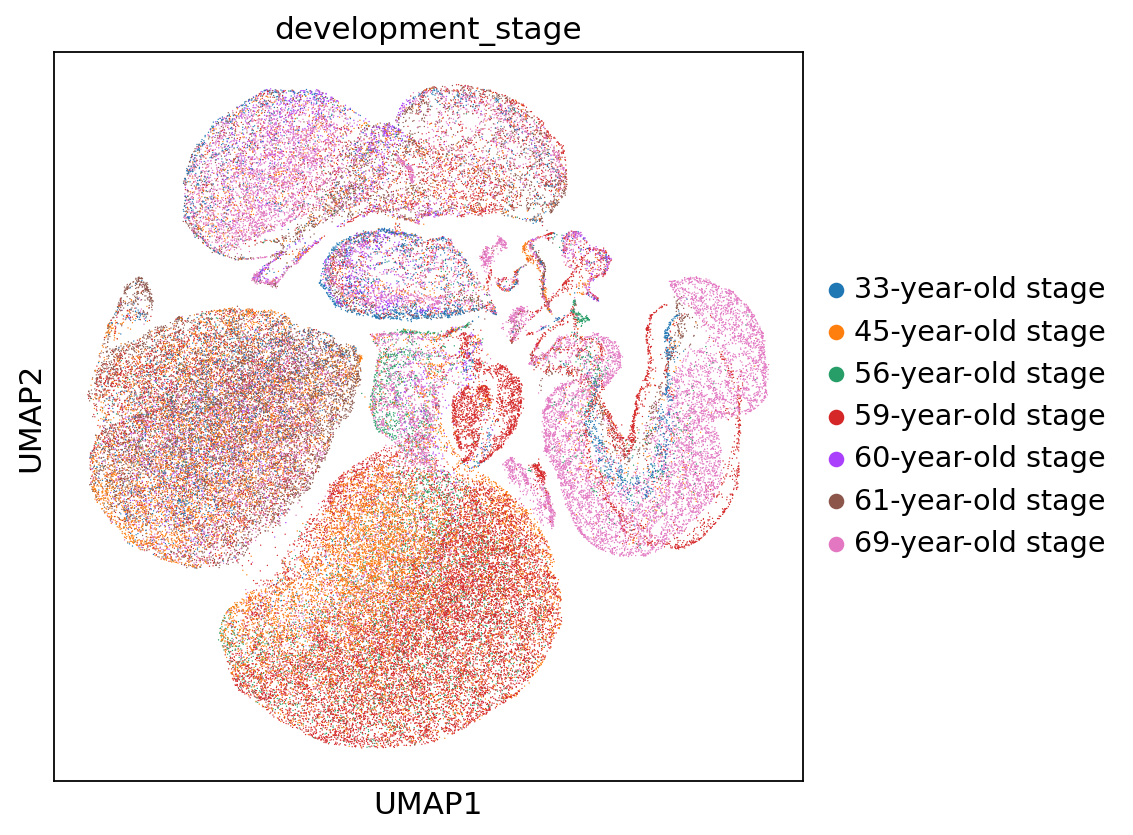

In [20]:
# Inital setting for plot size
from matplotlib import rcParams

FIGSIZE = (6, 6)
rcParams["figure.figsize"] = FIGSIZE

sc.pl.umap(adata_D.to_memory(), color=["development_stage"])
#sc.pl.umap(adata_D, color=["batch", "louvain"])

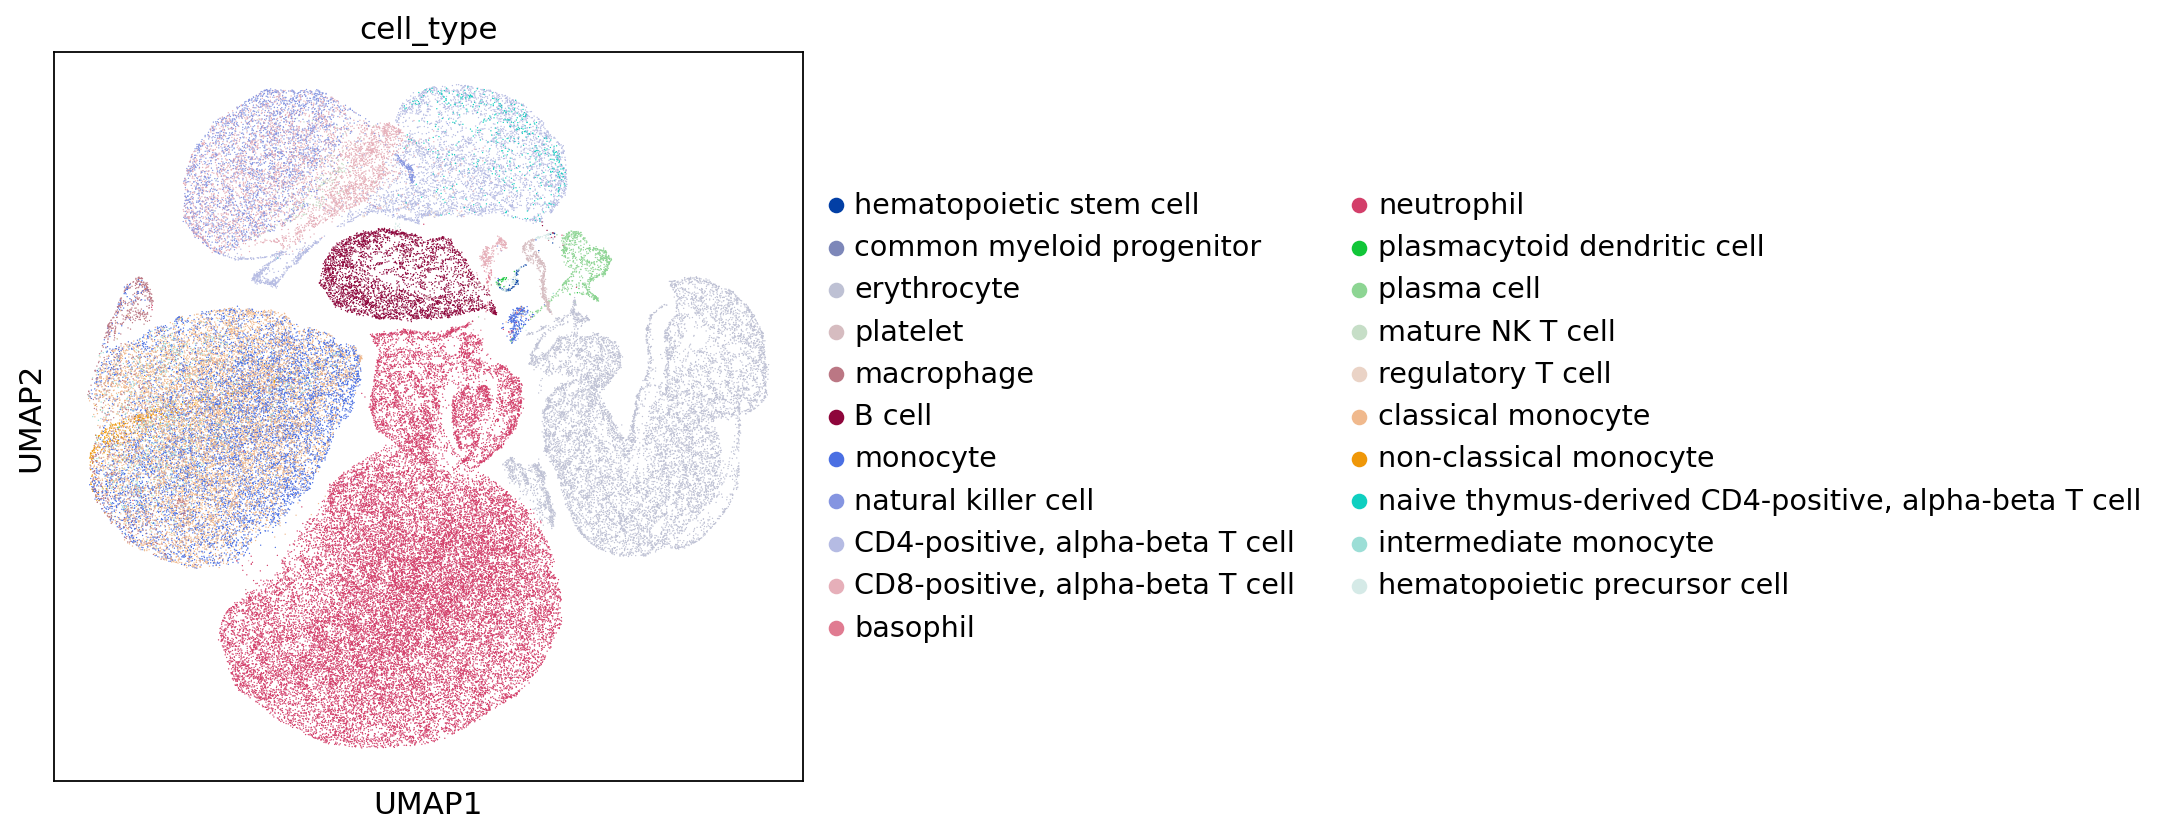

In [22]:
# Inital setting for plot size
from matplotlib import rcParams

FIGSIZE = (6, 6)
rcParams["figure.figsize"] = FIGSIZE

sc.pl.umap(adata_D.to_memory(), color=["cell_type"])
#sc.pl.umap(adata_D, color=["batch", "louvain"])